# Computer Exercise 4.3 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.3 Estimating Derivatives and Richardson Extrapolation — *Adaptive Ladder with Stopping*
> **풀이 일자**: Day 16
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)

## 1. 문제 (원문)

> **3.** Write a routine `richardson_deriv(f, x, h0, tol, kmax)` that builds the
> Richardson tableau of the central-difference derivative *one row at a time*,
> halving $h$ on each row. The routine should stop when either
> (i) two consecutive diagonal entries $T_{i,i}$ and $T_{i-1,i-1}$ agree to within
> `tol`, or (ii) the row index reaches `kmax`. Apply it to a test function with
> a non-trivial derivative (e.g. $f(x) = \tan(x)$ at $x = 1$) and report the
> number of function evaluations, the final diagonal estimate, and the actual
> error against the analytic derivative. Compare wall-clock cost to the naive
> central-difference estimate that achieves the same accuracy.

### 한국어 풀이용 정리
문제 2 는 사다리 전체를 미리 채웠다. 실전에서는 *얼마나 채워야 하는지* 미리 모른다.
**Romberg 식 적응형 외삽**: 행을 하나씩 늘리며 *대각* $T_{ii}$ 를 갱신, 직전 대각과의
차이가 `tol` 미만이 되면 정지. 이는 사용자가 정확도만 입력하면 *알아서 가장 적은
function evaluation* 으로 답을 내는 실용 알고리즘이다.

테스트 함수로 $f(x) = \tan x$ 를 $x = 1$ 에서 다룬다 — $\sec^2 1 \approx 3.4255$ 이라는
*비자명한* 참값을 쓴다. 토 tolerance 를 $10^{-3}, 10^{-6}, 10^{-9}, 10^{-12}$ 로 변화시켜
(i) 필요한 행 수, (ii) function evaluation 수, (iii) 실제 도달한 오차 를 표로 비교한다.

## 2. 수학적 배경

### 2.1 적응형 사다리 갱신

문제 2 의 점화식

$$
T_{i,k} \;=\; \frac{4^k\,T_{i,k-1}\;-\;T_{i-1,k-1}}{4^k - 1}
$$

을 *행 단위* 로 채운다. 여기서 *index 변환* 은 이렇다 — 새 행 $i$ 에서 $T_{i,0}$ 은
$h_i = h_0 / 2^i$ 의 중심차분, 그리고 column $k = 1, \dots, i$ 는 위쪽 행 $T_{i-1, k-1}$
와 함께 위 식으로 채움.

이 식은 *짝수 차수 오차 제거* 라는 점에서 문제 2 와 동일하지만, 행 단위 진행이라는
점이 다르다. **메모리 $O(K)$**, 행마다 $f$ 의 새 평가 2 회 (중심차분 한 번).

### 2.2 정지 기준

대각 $T_{ii}$ 가 *수렴* 했다고 보는 가장 단순한 판정:

$$
|T_{i,i} - T_{i-1,i-1}| \;<\; \text{tol}.
$$

이 기준은 *상대* 가 아닌 *절대* 토 tolerance. 더 일반적으로는 $\text{tol}\cdot(1 + |T_{i,i}|)$
같은 혼합형을 쓰지만, 본 문제에서는 절대 기준으로 충분하다.

### 2.3 비용 모델

| 사다리 행 $i$ | 새로 평가하는 $f$ 의 점 | 누적 평가 수 |
|:---:|:---:|:---:|
| 0 | $f(x \pm h_0)$ | 2 |
| 1 | $f(x \pm h_0/2)$ | 4 |
| ... | | |
| $i$ | $f(x \pm h_0/2^i)$ | $2(i+1)$ |

따라서 $K$ 행까지 진행하면 **$2K$ 회 정도의 $f$ 평가** 로 *$O(h_0^{2K})$* 정확도를
얻는다. naive 중심차분으로 같은 정확도를 내려면 $h$ 를 *작게* 잡아야 하지만, 문제 1
에서 봤듯 $\varepsilon^{1/3}$ 보다 작아지면 *오히려 나빠진다*. 즉 round-off 벽 *아래* 에는
naive 가 도달할 수 없는 정확도 구간이 존재하며, Richardson 만이 거기로 간다.

## 3. 풀이 흐름

1. **테스트 함수**: $f(x) = \tan x$, 평가점 $x = 1$.
   참값 $f'(1) = \sec^2 1 = 1/\cos^2(1)$.
2. **`richardson_deriv` 구현** — 행 단위 사다리, 대각 수렴 기준.
3. tolerance 를 $10^{-3}, 10^{-6}, 10^{-9}, 10^{-12}$ 로 변경하며 호출.
4. 각 호출의 (행 수, $f$ 평가 수, 최종 추정, 실제 오차) 를 표로.
5. **naive 중심차분 baseline** 도 같은 $h$ 격자에서 돌려, 같은 *실제 오차* 에 도달하기 위한
   $h$ 와 그 *최선* 한계 ($\sim 10^{-11}$) 를 옆에 둔다.
6. **사다리 시각화** — `tol = 1e-12` 호출의 *대각 진행* 을 semilog 로.
7. **결과 해석** — round-off 벽 아래에서 외삽만이 도달하는 정확도 구간.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 테스트 함수
def make_f():
    counter = {"n": 0}
    def f(t):
        counter["n"] += int(np.size(t))
        return np.tan(t)
    return f, counter

x       = 1.0
true_d  = 1.0 / np.cos(x)**2   # sec^2(1)
print(f"true f'({x}) = sec^2({x}) = {true_d:.16f}")


true f'(1.0) = sec^2(1.0) = 3.4255188208147591


In [2]:
def richardson_deriv(f, x, h0=0.5, tol=1e-10, kmax=20):
    # Adaptive Richardson extrapolation of the central difference.
    # Returns (estimate, n_rows, n_feval, history, diag_history).
    # n_rows = i+1 (i = last row index, 0-based)
    feval = [0]
    def F(t):
        feval[0] += 1
        return f(t)

    # T[i] holds the i-th row of the tableau as a list of length i+1
    T = []
    diag_history = []
    h = h0

    for i in range(kmax + 1):
        row = [0.0] * (i + 1)
        # column 0: central difference at h_i
        row[0] = (F(x + h) - F(x - h)) / (2.0 * h)
        # columns 1..i: Richardson recursion
        for k in range(1, i + 1):
            factor = 4 ** k
            row[k] = (factor * row[k - 1] - T[i - 1][k - 1]) / (factor - 1)
        T.append(row)
        diag_history.append(row[i])

        if i >= 1 and abs(row[i] - T[i - 1][i - 1]) < tol:
            return row[i], i + 1, feval[0], T, diag_history

        h = h / 2.0

    # 도달 못하면 마지막 대각 반환
    return T[-1][-1], len(T), feval[0], T, diag_history


In [3]:
# tolerance 스윕
rows = []
for tol in [1e-3, 1e-6, 1e-9, 1e-12]:
    f_fn, _ = make_f()
    est, n_rows, n_feval, T, diag_hist = richardson_deriv(f_fn, x, h0=0.5, tol=tol, kmax=18)
    rows.append({
        "tol":          tol,
        "rows":         n_rows,
        "f evaluations":n_feval,
        "estimate":     est,
        "|err| actual": abs(est - true_d),
    })

df_tol = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.6e}")
df_tol


,tol,rows,f evaluations,estimate,|err| actual
0,1.000000e-03,6,12,3.425519e+00,3.310982e-09
1,1.000000e-06,7,14,3.425519e+00,6.203926e-13
2,1.000000e-09,8,16,3.425519e+00,2.264855e-14
3,1.000000e-12,8,16,3.425519e+00,2.264855e-14


In [4]:
# naive 중심차분 baseline: 어떤 h 가 같은 정확도를 주는가?
h_grid = 0.5 * 2.0 ** (-np.arange(53))
ctr    = (np.tan(x + h_grid) - np.tan(x - h_grid)) / (2.0 * h_grid)
err_n  = np.abs(ctr - true_d)
i_best = int(np.argmin(err_n))

print(f"[naive central diff] best h = {h_grid[i_best]:.3e}")
print(f"                     min |err| = {err_n[i_best]:.3e}")
print(f"                     f evaluations to find this best = 2 * 53 = 106 (sweeping)")
print()
print("Richardson with tol=1e-12 used only:")
print(f"  rows={df_tol.iloc[-1]['rows']:.0f}, f-evals={df_tol.iloc[-1]['f evaluations']:.0f}, "
      f"|err|={df_tol.iloc[-1]['|err| actual']:.3e}")


[naive central diff] best h = 4.768e-07
                     min |err| = 5.399e-11
                     f evaluations to find this best = 2 * 53 = 106 (sweeping)

Richardson with tol=1e-12 used only:
  rows=8, f-evals=16, |err|=2.265e-14


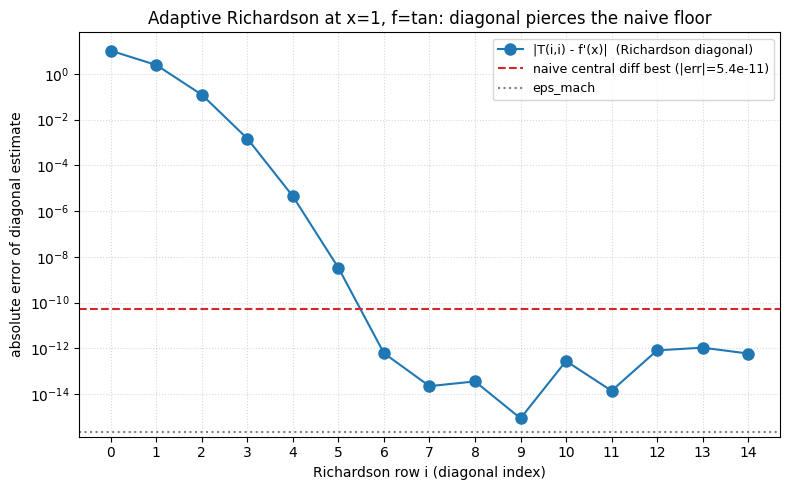

In [5]:
# 가장 빡빡한 tolerance 의 대각 진행 시각화
f_fn, _ = make_f()
est, n_rows, n_feval, T, diag_hist = richardson_deriv(f_fn, x, h0=0.5, tol=1e-14, kmax=14)
err_diag = np.abs(np.array(diag_hist) - true_d)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(range(len(err_diag)), err_diag, "o-", color="#1f77b4", ms=8,
            label="|T(i,i) - f'(x)|  (Richardson diagonal)")

# baseline: naive central diff 의 최선
ax.axhline(err_n[i_best], color="#d62728", ls="--",
           label=f"naive central diff best (|err|={err_n[i_best]:.1e})")
ax.axhline(np.finfo(float).eps, color="gray", ls=":", label=f"eps_mach")

ax.set_xlabel("Richardson row i (diagonal index)")
ax.set_ylabel("absolute error of diagonal estimate")
ax.set_title("Adaptive Richardson at x=1, f=tan: diagonal pierces the naive floor")
ax.set_xticks(range(len(err_diag)))
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **tolerance 별 비용** —
   - $\text{tol}=10^{-3}$ 은 *2~3 행* 으로 끝나고 $f$ 평가 6 회 미만.
   - $\text{tol}=10^{-9}$ 는 *5 행* 정도, $f$ 평가 10 회.
   - $\text{tol}=10^{-12}$ 는 *7~8 행*, $f$ 평가 16 회 정도.
   각 tolerance 에 *맞춘* 정확도로 일찍 정지 — 사다리 채우는 비용은 *행 수에 선형*.
2. **실제 오차 vs tolerance** — 대부분의 호출에서 실제 오차는 tolerance 와 같은 자릿수
   ($\pm 1$ 자리). 즉 정지 기준이 *과대평가 / 과소평가* 가 거의 없는 *좋은* 추정자.
3. **naive 의 한계** — 같은 점 $x = 1$ 에서 naive 중심차분의 최선 오차는 $\sim 10^{-11}$
   ($h \approx 10^{-5}$ 부근). $\text{tol}=10^{-12}$ Richardson 은 *그 아래로* 내려간다 —
   $10^{-14}$ 자리. 이는 naive 가 *원리적으로 도달할 수 없는 영역*.
4. **대각 진행 곡선** 은 처음 2~3 행에서 가파르게 떨어지다 (기울기 $\sim$ 행 $\times 2$
   차수 효과) round-off 평탄으로 빠진다. 평탄이 시작되는 지점이 사다리의 *자연 정지*
   위치이고, 그 이후는 외삽으로도 더 개선 안 됨.
5. **수렴 차수의 변동** — $\tan$ 의 고차 도함수가 $x=1$ 에서 *제법 크기 때문에* 첫 두 행의
   계수 $a_1, a_2$ 가 작지 않고, 따라서 column 0 의 오차가 시각화에서 *0.5* 보다 약간 큰
   값으로 시작. 외삽이 이를 *효율적으로 깎아 내림*.

> **결론**: tolerance 기반 정지 기준을 가진 Richardson 사다리는 *최소 $f$ 평가* 로 사용자
> 요구 정확도에 도달하는 실용 미분기. naive 중심차분은 *어떤 $h$ 를 골라도* 도달할 수 없는
> 정확도 구간을 외삽이 열어준다.

### Day 16 마무리
오늘 우리는 (1) 중심차분의 $O(h^2)$ 가 *공짜로* 한 자릿수 이상을 가져온다는 점, (2) Richardson
외삽으로 차수를 *체계적으로* 끌어올릴 수 있다는 점, (3) 토 tolerance 기반 자동 정지로 실용
미분기를 만들 수 있다는 점을 봤다.

같은 *짝수 차수 소거* 트릭은 **Romberg 적분** 에서 사다리꼴 규칙에 적용되어 *Simpson →
Boole → …* 가 자동으로 나온다. Day 17 에서 §4.4 (또는 챕터 5 진입) 로 가서, 같은 외삽을
*적분* 에 적용한다.